In [10]:
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import math
from torch.nn import functional as F
import matplotlib as mpl

In [11]:
mpl.rcParams['font.sans-serif'] = ['SimHei']  # 使用黑体
mpl.rcParams['axes.unicode_minus'] = False  # 正确显示负号

# 检查GPU是否可用
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

# 设置随机种子以确保结果可重现
torch.manual_seed(42)
np.random.seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

使用设备: cuda


In [12]:
df = pd.read_csv('./data/Temperature.csv')

# 打印一些基本信息
print(f"数据集共有 {len(df)} 行")
print(f"数据集共有 {len(df.columns)} 列")
print(f"列名: {list(df.columns)}")

# 确保获取正确的列
# 第一列是索引，第二列是日期，第三列是温度
if len(df.columns) >= 3:
    # 获取列名
    temp_col = df.columns[2]  # 第三列作为温度列
    print(f"温度列名: {temp_col}")
else:
    # 如果列数不足，可能数据结构有问题
    print("警告：数据集列数不符合预期！")
    temp_col = df.columns[1] if len(df.columns) > 1 else df.columns[0]

date_col = df.columns[1]
print(f"日期列名: {date_col}")

# 打印前几行数据，查看数据结构
print("\n数据集前5行:")
print(df.head())

# 转换为datetime类型
df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
print(f"\n转换后的日期类型: {df[date_col].dtype}")

# 检查是否有转换失败的日期
nan_dates = df[date_col].isna().sum()
print(f"无法转换为日期的行数: {nan_dates}")

# 创建日期验证函数
def is_valid_date(date):
    if pd.isnull(date):
        return False
     
    # 处理2月29日 - 只在闰年有效
    if date.month == 2 and date.day == 29:
        year = date.year
        # 闰年检查：能被4整除，但不能被100整除，除非也能被400整除
        is_leap = (year % 4 == 0) and (year % 100 != 0 or year % 400 == 0)
        return is_leap
     
    # 检查其他无效的月/日组合
    days_in_month = {
        1: 31, 2: 28, 3: 31, 4: 30, 5: 31, 6: 30,
        7: 31, 8: 31, 9: 30, 10: 31, 11: 30, 12: 31
    }
     
    # 为闰年调整2月天数
    if date.month == 2 and (date.year % 4 == 0) and (date.year % 100 != 0 or date.year % 400 == 0):
        days_in_month[2] = 29
     
    return date.month in days_in_month and date.day <= days_in_month[date.month]

# 筛选出具有无效日期的行
valid_date_mask = df[date_col].apply(is_valid_date)
invalid_dates = df[~valid_date_mask]

print(f"\n找到的无效日期数量: {len(invalid_dates)}")

if len(invalid_dates) > 0:
    print(f"发现 {len(invalid_dates)} 个无效日期，将被移除：")
    print(invalid_dates[[date_col, temp_col]].head())
    
    # 移除无效日期
    df = df[valid_date_mask]
    print(f"移除无效日期后剩余的数据点: {len(df)}")
else:
    print("没有发现无效日期")
    print(f"数据集中所有日期都是有效的 ({len(df)} 行)")

数据集共有 37200 行
数据集共有 3 列
列名: ['Unnamed: 0', 'date', 'meant']
温度列名: meant
日期列名: date

数据集前5行:
   Unnamed: 0      date  meant
0           0  19020101   20.1
1           1  19020201   14.0
2           2  19020301   13.4
3           3  19020401   17.9
4           4  19020501   25.6

转换后的日期类型: datetime64[ns]
无法转换为日期的行数: 0

找到的无效日期数量: 0
没有发现无效日期
数据集中所有日期都是有效的 (37200 行)


In [13]:
# 处理缺失数据 (-999)
df[temp_col] = df[temp_col].replace(-999, np.nan)

# 填充缺失值 (使用前后温度的均值)
df[temp_col] = df[temp_col].interpolate(method='linear')

# 检查是否还有缺失值
if df[temp_col].isna().any():
    print(f"警告：填充后仍有 {df[temp_col].isna().sum()} 个缺失值")
    # 对于头尾可能无法插值的数据，使用最近的有效值填充
    df[temp_col] = df[temp_col].fillna(method='ffill')
    df[temp_col] = df[temp_col].fillna(method='bfill')

# 提取温度数据
temperature_data = df[temp_col].values.reshape(-1, 1)
print(f"温度数据范围: {temperature_data.min()} 到 {temperature_data.max()}")
print(f"温度数据平均值: {temperature_data.mean()}")

温度数据范围: 2.6 到 33.0
温度数据平均值: 22.32287231182796


In [14]:
# 添加额外特征：温度变化率和季节性特征
def weather_features(data):
    n = len(data)
    features = np.zeros((n, 3))  # 原始温度, 变化率, 时间周期特征
    
    # 复制原始温度数据
    features[:, 0] = data.flatten()
    
    # 计算变化率 (一阶差分)
    features[1:, 1] = np.diff(data.flatten())
    
    # 添加周期性时间特征 (假设是按天采样，周期为365天)
    # 使用正弦和余弦函数捕捉时间的周期性
    period = 365  # 假设周期为365天
    for i in range(n):
        features[i, 2] = math.sin(2 * math.pi * (i % period) / period)
    
    return features

# 创建扩展特征
extended_features = weather_features(temperature_data)
print(f"扩展特征形状: {extended_features.shape}")

# 对扩展特征进行标准化处理
scaler = StandardScaler()  # 使用StandardScaler替代MinMaxScaler
normalized_data = scaler.fit_transform(extended_features)

扩展特征形状: (37200, 3)


In [15]:
# 创建输入/输出序列对
input_window = 30  
X, y = [], []
for i in range(len(normalized_data) - input_window):
    X.append(normalized_data[i:i + input_window])
    y.append(normalized_data[i + input_window, 0])  # 只预测温度，不预测其他特征

X = np.array(X)
y = np.array(y)

# 划分训练集和测试集
train_ratio = 0.9
split_idx = int(len(X) * train_ratio)

X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

print(f"总数据点: {len(X)}, 训练集大小: {len(X_train)}, 测试集大小: {len(X_test)}")
print(f"X_train 形状: {X_train.shape}, X_test 形状: {X_test.shape}")

# 转换为PyTorch张量
X_train = torch.FloatTensor(X_train)
y_train = torch.FloatTensor(y_train)
X_test = torch.FloatTensor(X_test)
y_test = torch.FloatTensor(y_test)

总数据点: 37170, 训练集大小: 33453, 测试集大小: 3717
X_train 形状: (33453, 30, 3), X_test 形状: (3717, 30, 3)


In [16]:
# 定义注意力机制
class AttentionLayer(nn.Module):
    def __init__(self, hidden_size):
        super(AttentionLayer, self).__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_size, hidden_size // 2),
            nn.Tanh(),
            nn.Linear(hidden_size // 2, 1),
            nn.Softmax(dim=1)
        )
        
    def forward(self, lstm_output):
        # lstm_output shape: [batch, seq_len, hidden_size]
        attn_weights = self.attention(lstm_output)  # [batch, seq_len, 1]
        context = torch.sum(attn_weights * lstm_output, dim=1)  # [batch, hidden_size]
        return context, attn_weights

In [17]:
# 定义温度预测模型
class TemperaturePredictor(nn.Module):
    def __init__(self, input_size=3, hidden_size=256, num_layers=3):
        super(TemperaturePredictor, self).__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,  # 每个时间步的特征数（温度、变化率、周期）
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.3 if num_layers > 1 else 0,
            bidirectional=True  # 使用双向LSTM
        )
        
        # 注意力层
        self.attention = AttentionLayer(hidden_size * 2)  # *2 因为是双向LSTM
        
        # 残差连接后的层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size * 2, 128),
            nn.LeakyReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(0.3),
            nn.Linear(128, 64),
            nn.LeakyReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(0.2),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        # LSTM output
        lstm_out, _ = self.lstm(x)  # [batch, seq_len, hidden_size*2]
        
        # 应用注意力机制
        context, _ = self.attention(lstm_out)  # [batch, hidden_size*2]
        
        # 全连接层
        output = self.fc(context)
        return output.squeeze()

In [18]:
# 创建新损失函数，对高温区域给予更高权重
class WeightedMSELoss(nn.Module):
    def __init__(self, threshold=0.7, high_weight=2.0):
        super(WeightedMSELoss, self).__init__()
        self.threshold = threshold
        self.high_weight = high_weight
        
    def forward(self, y_pred, y_true):
        # 基本MSE
        mse = F.mse_loss(y_pred, y_true, reduction='none')
        
        # 为高温区域分配更高的权重
        # 假设y_true是标准化后的值，高于threshold认为是高温
        weights = torch.ones_like(y_true)
        weights = torch.where(y_true > self.threshold, 
                             self.high_weight * torch.ones_like(y_true), 
                             weights)
        
        # 应用权重
        weighted_mse = (weights * mse).mean()
        return weighted_mse

In [19]:
# 创建模型实例并移到GPU
model = TemperaturePredictor(input_size=3, hidden_size=256, num_layers=3).to(device)

# 定义损失函数和优化器
criterion = WeightedMSELoss(threshold=0.7, high_weight=2.0)
optimizer = optim.AdamW(model.parameters(), lr=0.0005, weight_decay=1e-5)

# 使用更复杂的学习率调度器，移除 verbose 参数
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.7, patience=5, min_lr=1e-6
)

# 创建数据加载器进行批处理
batch_size = 64  # 适当减小批量大小以提高随机性
train_dataset = torch.utils.data.TensorDataset(X_train, y_train)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=batch_size, shuffle=True, pin_memory=True
)

In [20]:
# 训练模型
epochs = 60  # 增加训练轮次
train_losses = []
val_losses = []
best_loss = float('inf')
patience = 10  # 增加早停耐心值
counter = 0

for epoch in range(epochs):
    # 训练阶段
    model.train()
    epoch_loss = 0
    
    for batch_X, batch_y in train_loader:
        # 将数据移到设备上
        batch_X = batch_X.to(device)
        batch_y = batch_y.to(device)
        
        optimizer.zero_grad()
        
        # 前向传播
        y_pred = model(batch_X)
        
        # 计算损失
        loss = criterion(y_pred, batch_y)
        
        # 反向传播
        loss.backward()
        
        # 梯度裁剪，防止梯度爆炸
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        
        # 更新参数
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # 计算平均训练损失
    avg_train_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_train_loss)
    
    # 验证阶段
    model.eval()
    with torch.no_grad():
        # 使用一小部分训练数据作为验证集
        val_size = min(1000, len(X_train))
        val_indices = np.random.choice(len(X_train), val_size, replace=False)
        X_val = X_train[val_indices].to(device)
        y_val = y_train[val_indices].to(device)
        
        val_pred = model(X_val)
        val_loss = criterion(val_pred, y_val)
        val_losses.append(val_loss.item())
    
    # 更新学习率
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}')
    
    # 早停策略
    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), 'best_temperature_model_improved.pt')
    else:
        counter += 1
        if counter >= patience and epoch > 50:  # 确保至少训练50轮
            print(f"Early stopping at epoch {epoch + 1}")
            break

Epoch [10/60], Train Loss: 0.163355, Val Loss: 0.120474
Epoch [20/60], Train Loss: 0.124748, Val Loss: 0.113666
Epoch [30/60], Train Loss: 0.119976, Val Loss: 0.085553
Epoch [40/60], Train Loss: 0.116295, Val Loss: 0.086311
Epoch [50/60], Train Loss: 0.109471, Val Loss: 0.081663
Early stopping at epoch 54


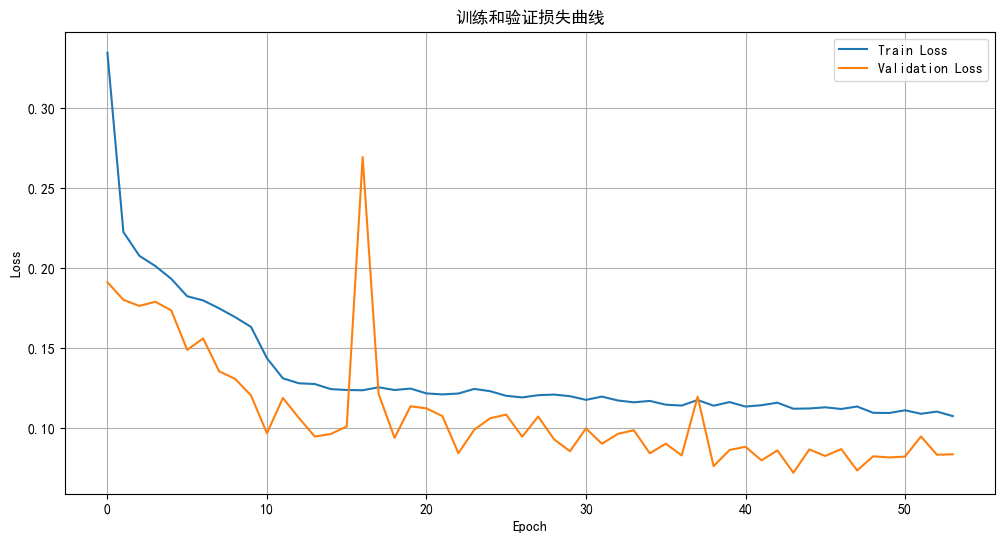

In [21]:
# 绘制训练和验证损失
plt.figure(figsize=(12, 6))
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('训练和验证损失曲线')
plt.legend()
plt.grid(True)
plt.savefig('loss_curves.png', dpi=300)
plt.show()

In [22]:
# 加载最佳模型
model.load_state_dict(torch.load('best_temperature_model_improved.pt'))

# 测试模型
model.eval()
with torch.no_grad():
    X_test_gpu = X_test.to(device)
    y_pred = model(X_test_gpu)

# 准备逆变换
# 只关心温度值，不关心其他特征
y_pred_np = y_pred.cpu().numpy().reshape(-1, 1)  # 预测的是标准化后的温度
y_test_np = y_test.cpu().numpy().reshape(-1, 1)  # 实际的标准化后的温度

# 创建完整的特征数组用于逆变换
y_pred_full = np.zeros((len(y_pred_np), 3))
y_pred_full[:, 0] = y_pred_np.flatten()  # 只填充温度值
y_test_full = np.zeros((len(y_test_np), 3))
y_test_full[:, 0] = y_test_np.flatten()  # 只填充温度值

# 逆变换回原始温度
y_pred_transformed = scaler.inverse_transform(y_pred_full)[:, 0].reshape(-1, 1)
y_test_transformed = scaler.inverse_transform(y_test_full)[:, 0].reshape(-1, 1)

# 计算均方误差和平均绝对误差
def compute_metrics(observed, predicted):
    n = len(observed)
    mse = (1 / n) * np.sum(np.square(observed - predicted))
    mae = (1 / n) * np.sum(np.abs(observed - predicted))
    return mse, mae

mse, mae = compute_metrics(y_test_transformed, y_pred_transformed)
print(f'测试集上的均方误差 (MSE): {mse:.4f}')
print(f'测试集上的平均绝对误差 (MAE): {mae:.4f}')

测试集上的均方误差 (MSE): 2.3491
测试集上的平均绝对误差 (MAE): 1.1058


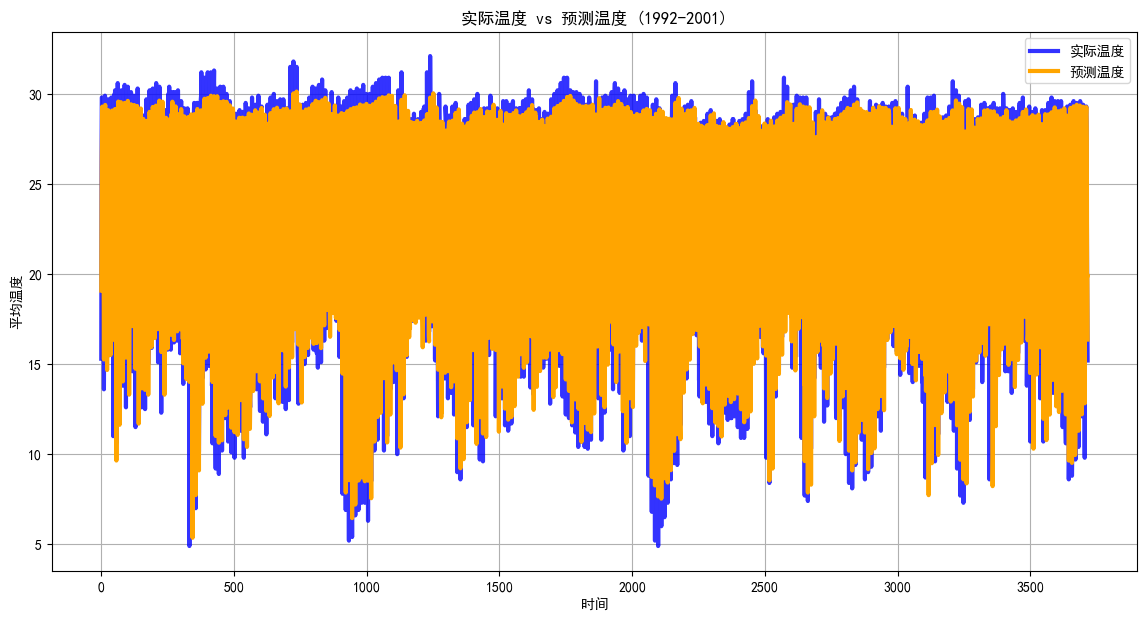

In [23]:
# 绘制结果
plt.figure(figsize=(14, 7))
plt.plot(y_test_transformed, label='实际温度', color='blue', linewidth=3,alpha=0.8)
plt.plot(y_pred_transformed, label='预测温度', color='orange', linewidth=3,alpha=1)
plt.fill_between(range(len(y_pred_transformed)),
                 y_pred_transformed.flatten(),
                 y_test_transformed.flatten(),
                 alpha=0.3)
plt.xlabel('时间')
plt.ylabel('平均温度')
plt.title('实际温度 vs 预测温度 (1992-2001)')
plt.legend()
plt.grid(True)
plt.savefig('improved_temperature_prediction.png', dpi=300)
plt.show()

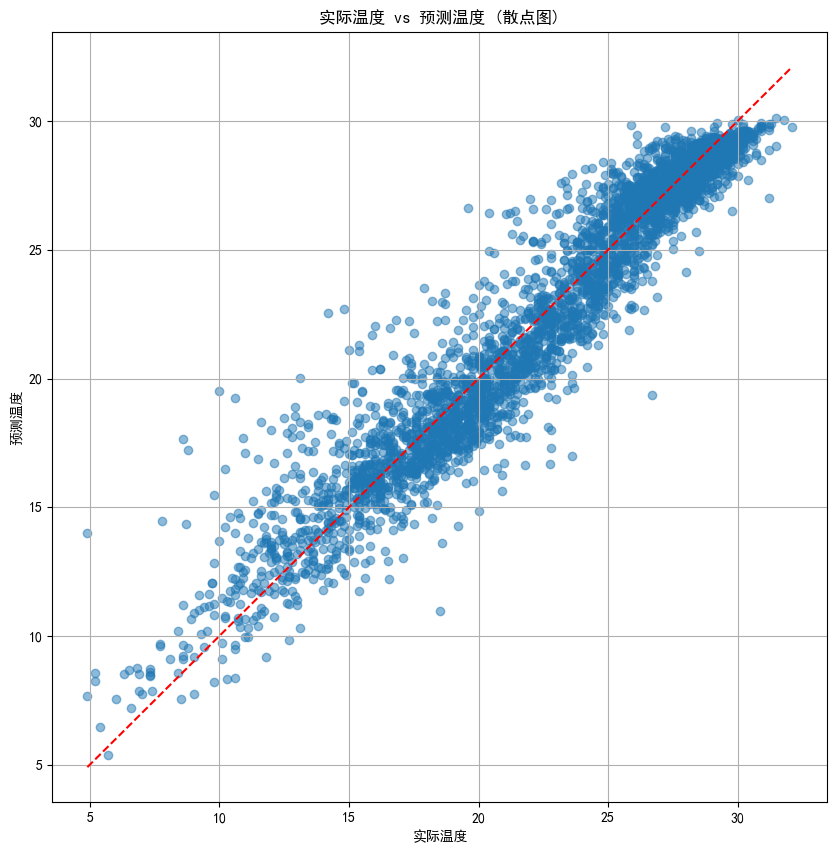

In [24]:
# 绘制散点图来查看预测值与实际值的相关性
plt.figure(figsize=(10, 10))
plt.scatter(y_test_transformed, y_pred_transformed, alpha=0.5)
plt.xlabel('实际温度')
plt.ylabel('预测温度')
plt.title('实际温度 vs 预测温度 (散点图)')
# 添加理想预测线
min_val = min(np.min(y_test_transformed), np.min(y_pred_transformed))
max_val = max(np.max(y_test_transformed), np.max(y_pred_transformed))
plt.plot([min_val, max_val], [min_val, max_val], 'r--')
plt.grid(True)
plt.savefig('temperature_correlation.png', dpi=300)
plt.show()

In [25]:
#baseline基线方法定义基础LSTM模型
class BaselineLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=128, num_layers=1):
        super(BaselineLSTM, self).__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0,
            bidirectional=False  # 单向LSTM
        )

        # 简单的全连接层
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        # x shape: [batch, seq_len, features]
        lstm_out, (h_n, _) = self.lstm(x)  # [batch, seq_len, hidden_size]

        # 使用最后一个时间步的输出
        out = self.fc(lstm_out[:, -1, :])
        return out.squeeze()

In [26]:
def train_baseline_model():
    # 创建模型实例
    baseline_model = BaselineLSTM(input_size=3, hidden_size=128, num_layers=1).to(device)

    # 定义损失函数和优化器
    baseline_criterion = nn.MSELoss()  # 使用标准MSE损失
    baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=0.001)

    # 训练模型
    epochs = 30  # baseline使用较少的训练轮次
    baseline_train_losses = []
    baseline_val_losses = []
    best_baseline_loss = float('inf')

    for epoch in range(epochs):
        # 训练阶段
        baseline_model.train()
        epoch_loss = 0

        for batch_X, batch_y in train_loader:
            # 将数据移到设备上
            batch_X = batch_X.to(device)
            batch_y = batch_y.to(device)

            baseline_optimizer.zero_grad()

            # 前向传播
            y_pred = baseline_model(batch_X)

            # 计算损失
            loss = baseline_criterion(y_pred, batch_y)

            # 反向传播
            loss.backward()

            # 更新参数
            baseline_optimizer.step()

            epoch_loss += loss.item()

        # 计算平均训练损失
        avg_train_loss = epoch_loss / len(train_loader)
        baseline_train_losses.append(avg_train_loss)
        
        # 验证阶段
        baseline_model.eval()
        with torch.no_grad():
            val_size = min(1000, len(X_train))
            val_indices = np.random.choice(len(X_train), val_size, replace=False)
            X_val = X_train[val_indices].to(device)
            y_val = y_train[val_indices].to(device)

            val_pred = baseline_model(X_val)
            val_loss = baseline_criterion(val_pred, y_val)
            baseline_val_losses.append(val_loss.item())

        if (epoch + 1) % 5 == 0:
            print(f'Baseline Epoch [{epoch + 1}/{epochs}], Train Loss: {avg_train_loss:.6f}, Val Loss: {val_loss:.6f}')

        # 保存最佳模型
        if val_loss < best_baseline_loss:
            best_baseline_loss = val_loss
            torch.save(baseline_model.state_dict(), 'best_baseline_model.pt')
    
    # 绘制训练和验证损失
    plt.figure(figsize=(12, 6))
    plt.plot(baseline_train_losses, label='Baseline Train Loss')
    plt.plot(baseline_val_losses, label='Baseline Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Baseline模型训练和验证损失曲线')
    plt.legend()
    plt.grid(True)
    plt.savefig('baseline_loss_curves.png', dpi=300)
    plt.show()

    return baseline_model

In [27]:
def compare_models(improved_model, baseline_model):
    # 确保两个模型都处于评估模式
    improved_model.eval()
    baseline_model.eval()

    with torch.no_grad():
        X_test_gpu = X_test.to(device)

        # 获取改进模型的预测
        improved_pred = improved_model(X_test_gpu)

        # 获取baseline模型的预测
        baseline_pred = baseline_model(X_test_gpu)

    # 将预测结果转换回原始温度值
    def inverse_transform_predictions(predictions):
        predictions_np = predictions.cpu().numpy().reshape(-1, 1)
        full_features = np.zeros((len(predictions_np), 3))
        full_features[:, 0] = predictions_np.flatten()
        return scaler.inverse_transform(full_features)[:, 0].reshape(-1, 1)

    # 转换改进模型的预测
    improved_pred_temp = inverse_transform_predictions(improved_pred)

    # 转换baseline模型的预测
    baseline_pred_temp = inverse_transform_predictions(baseline_pred)

    # 转换实际值（与之前相同）
    y_test_np = y_test.cpu().numpy().reshape(-1, 1)
    y_test_full = np.zeros((len(y_test_np), 3))
    y_test_full[:, 0] = y_test_np.flatten()
    y_test_temp = scaler.inverse_transform(y_test_full)[:, 0].reshape(-1, 1)

    # 计算并打印两个模型的指标
    improved_mse, improved_mae = compute_metrics(y_test_temp, improved_pred_temp)
    baseline_mse, baseline_mae = compute_metrics(y_test_temp, baseline_pred_temp)

    print("模型性能比较:")
    print(f"{'模型':<20} {'MSE':<10} {'MAE':<10}")
    print(f"{'-' * 40}")
    print(f"{'改进的LSTM+注意力':<20} {improved_mse:<10.4f} {improved_mae:<10.4f}")
    print(f"{'Baseline LSTM':<20} {baseline_mse:<10.4f} {baseline_mae:<10.4f}")
    print(
        f"{'改进百分比':<20} {(baseline_mse - improved_mse) / baseline_mse * 100:<10.2f}% {(baseline_mae - improved_mae) / baseline_mae * 100:<10.2f}%")

    # 绘制比较图
    plt.figure(figsize=(14, 7))
    plt.plot(y_test_temp, label='实际温度', color='blue', linewidth=2, alpha=0.8)
    plt.plot(improved_pred_temp, label='改进模型预测', color='red', linewidth=2, alpha=0.7)
    plt.plot(baseline_pred_temp, label='Baseline模型预测', color='green', linewidth=2, alpha=0.7)
    plt.xlabel('时间')
    plt.ylabel('平均温度')
    plt.title('实际温度 vs 模型预测比较')
    plt.legend()
    plt.grid(True)
    plt.savefig('models_comparison.png', dpi=300)
    plt.show()

    # 绘制误差对比直方图
    plt.figure(figsize=(14, 6))

    improved_errors = np.abs(improved_pred_temp - y_test_temp).flatten()
    baseline_errors = np.abs(baseline_pred_temp - y_test_temp).flatten()

    plt.subplot(1, 2, 1)
    plt.hist(improved_errors, bins=30, alpha=0.7, color='red', label='改进模型误差')
    plt.hist(baseline_errors, bins=30, alpha=0.7, color='green', label='Baseline模型误差')
    plt.xlabel('预测误差（绝对值）')
    plt.ylabel('频率')
    plt.title('预测误差分布对比')
    plt.legend()
    plt.grid(True)

    plt.subplot(1, 2, 2)
    # 绘制误差散点图
    plt.scatter(y_test_temp, improved_errors, alpha=0.5, color='red', label='改进模型误差')
    plt.scatter(y_test_temp, baseline_errors, alpha=0.5, color='green', label='Baseline模型误差')
    plt.xlabel('实际温度')
    plt.ylabel('预测误差（绝对值）')
    plt.title('预测误差 vs 实际温度')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig('error_comparison.png', dpi=300)
    plt.show()


训练Baseline模型...
Baseline Epoch [5/30], Train Loss: 0.148091, Val Loss: 0.141092
Baseline Epoch [10/30], Train Loss: 0.116951, Val Loss: 0.108463
Baseline Epoch [15/30], Train Loss: 0.086855, Val Loss: 0.084799
Baseline Epoch [20/30], Train Loss: 0.083646, Val Loss: 0.076004
Baseline Epoch [25/30], Train Loss: 0.081245, Val Loss: 0.083909
Baseline Epoch [30/30], Train Loss: 0.079777, Val Loss: 0.081169


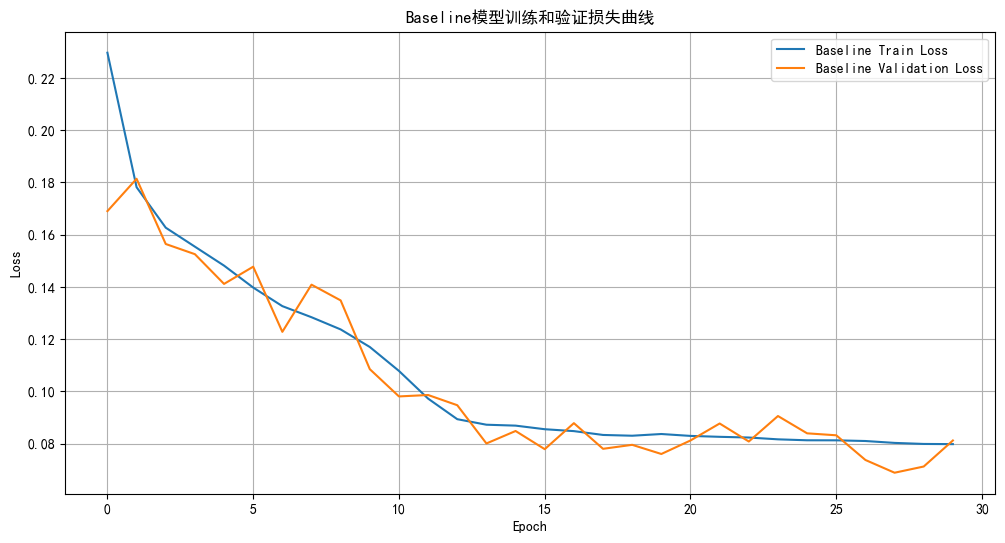

比较模型性能...
模型性能比较:
模型                   MSE        MAE       
----------------------------------------
改进的LSTM+注意力          2.3491     1.1058    
Baseline LSTM        2.4101     1.1118    
改进百分比                2.53      % 0.54      %


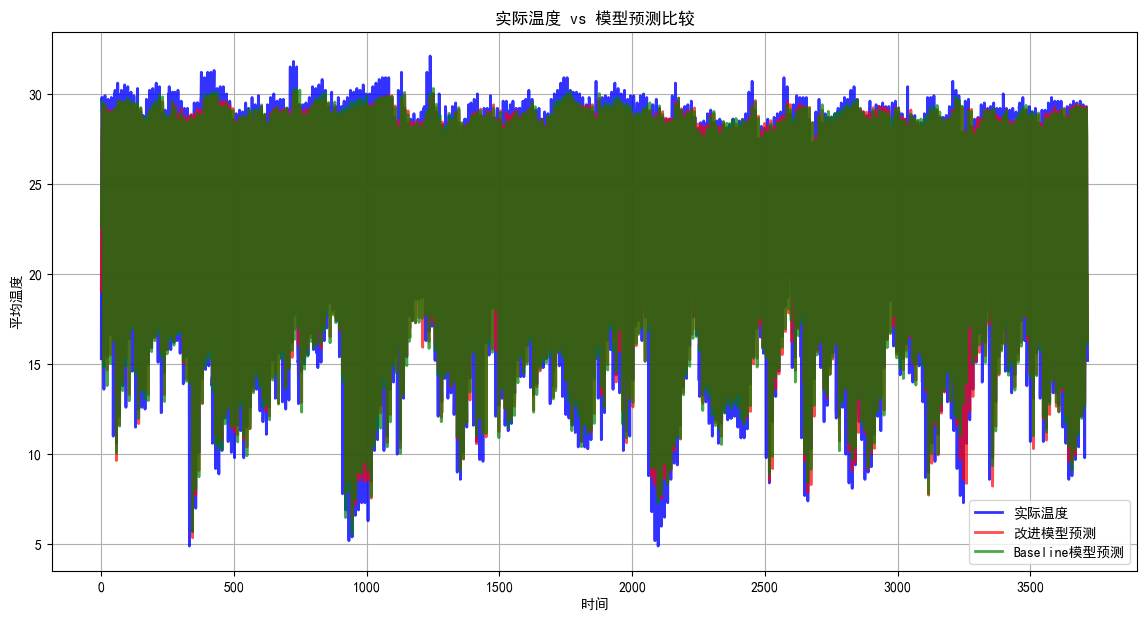

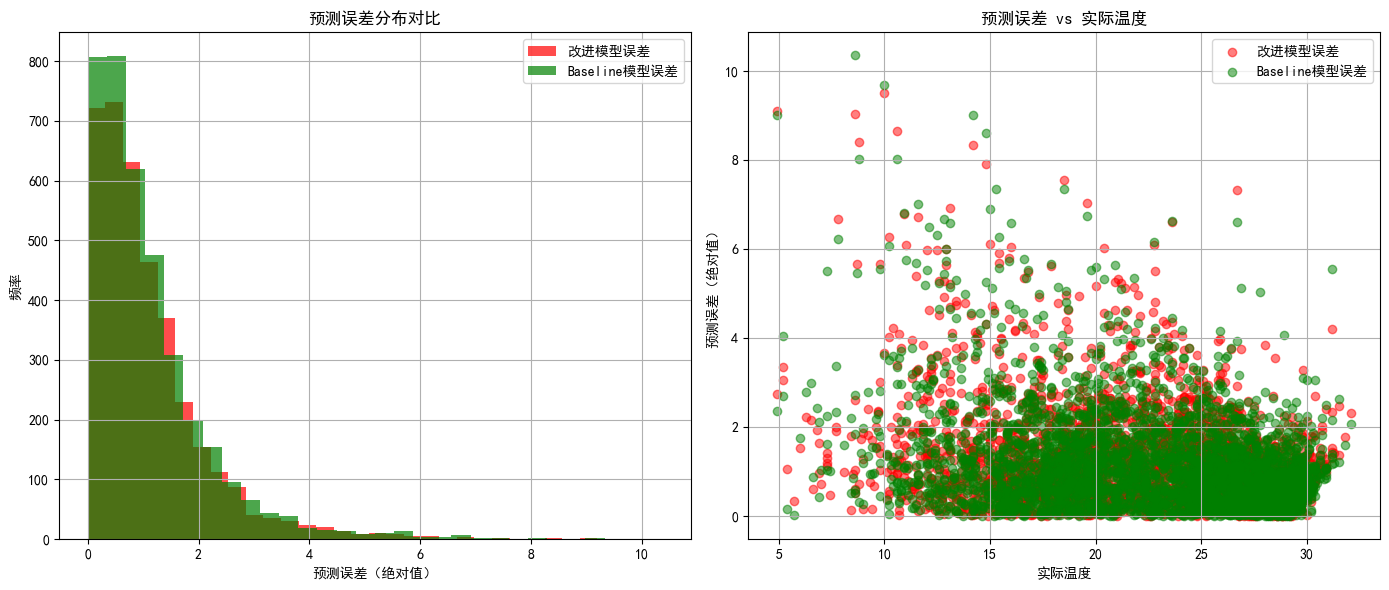

In [28]:
# 运行baseline训练和比较
print("训练Baseline模型...")
baseline_model = train_baseline_model()

# 加载最佳模型
baseline_model.load_state_dict(torch.load('best_baseline_model.pt'))

# 加载最佳改进模型
model.load_state_dict(torch.load('best_temperature_model_improved.pt'))

# 比较两个模型
print("比较模型性能...")
compare_models(model, baseline_model)

  #测试部分，预测任一天温度

测试集均方误差 (MSE): 2.349064
测试集平均绝对误差 (MAE): 1.105827


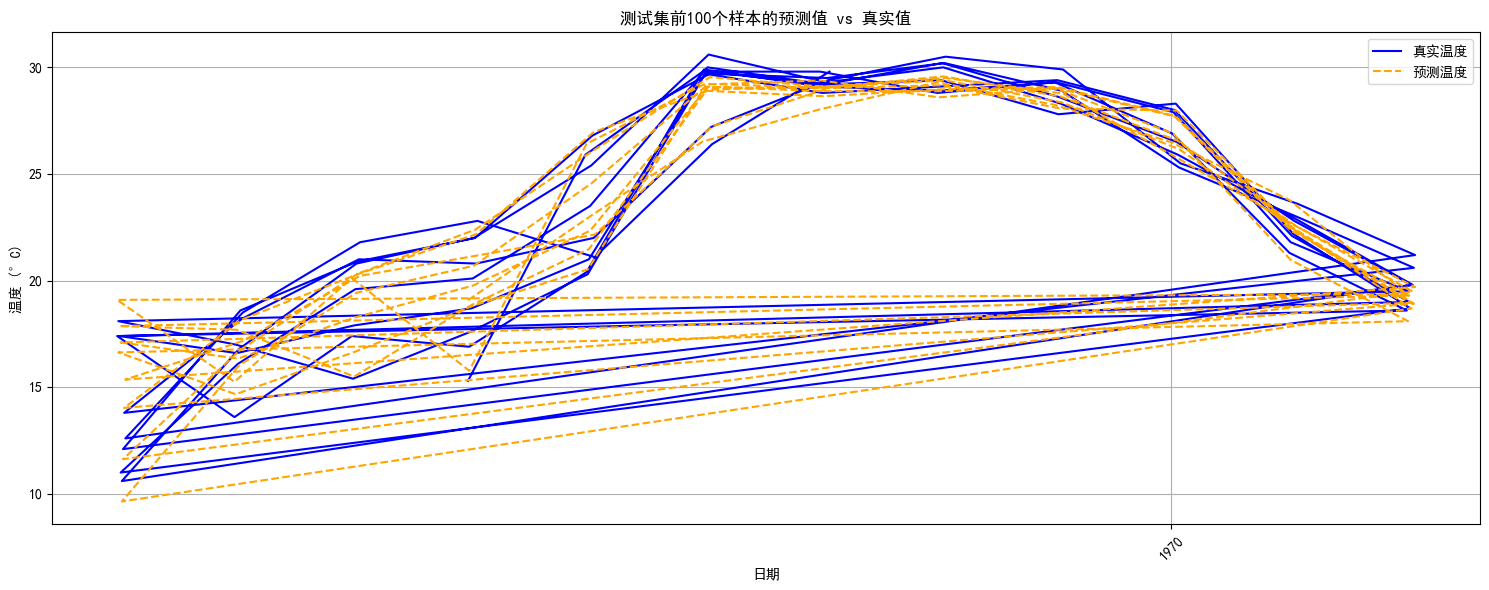

In [29]:

# 加载最佳模型
model.load_state_dict(torch.load('best_temperature_model_improved.pt'))
model.to(device)
model.eval()  # 设置模型为评估模式

# 对测试集进行预测
with torch.no_grad():
    X_test = X_test.to(device)
    y_pred = model(X_test).cpu().numpy()  # 预测结果转为numpy数组

# 获取温度列的均值和标准差以进行反标准化
temp_mean = scaler.mean_[0]  # 温度列是扩展特征的第一列
temp_std = scaler.scale_[0]

# 反标准化预测值和真实值
y_pred_original = y_pred * temp_std + temp_mean
y_test_original = y_test.numpy() * temp_std + temp_mean

# 计算评估指标：均方误差（MSE）和平均绝对误差（MAE）
mse = np.mean((y_pred_original - y_test_original) ** 2)
mae = np.mean(np.abs(y_pred_original - y_test_original))
print(f"测试集均方误差 (MSE): {mse:.6f}")
print(f"测试集平均绝对误差 (MAE): {mae:.6f}")

# 获取测试集对应的日期
test_dates = df[date_col].iloc[split_idx + input_window:].values

# 可视化前100个样本的预测值与真实值
plt.figure(figsize=(15, 6))
plt.plot(test_dates[:100], y_test_original[:100], label='真实温度', color='blue')
plt.plot(test_dates[:100], y_pred_original[:100], label='预测温度', color='orange', linestyle='--')
plt.xlabel('日期')
plt.ylabel('温度 (°C)')
plt.title('测试集前100个样本的预测值 vs 真实值')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)
plt.tight_layout()
plt.show()